So far we have seen around 26% churned, month-to-month customers churn most, etc. That is called descriptive analytics.

A machine learning model lets you predict what will happen next. All the historical data — every customer, their features, and whether they churned — and it learns the pattern. Then you give it a new customer it has never seen, and it tells you: "This person has a 78% chance of churning." That is predictive analytics.

We are building a Logistic Regression model. It is the simplest and most interpretable ML model for a Yes/No prediction — perfect for churn.

In [1]:
# The ML workflow — we follow this exact order:
#
# 1. PREPARE   → encode categories, select features, scale numbers
# 2. SPLIT     → 80% of data to train the model, 20% to test it
# 3. TRAIN     → model learns patterns from the training data
# 4. EVALUATE  → test on the 20% it has never seen — how accurate?
# 5. INTERPRET → which features matter most to the model?
# 6. PREDICT   → use on real new customers

print("Ready. Let's build the model.")

Ready. Let's build the model.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn — the machine learning library
from sklearn.model_selection  import train_test_split
from sklearn.linear_model    import LogisticRegression
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics         import (accuracy_score, classification_report,
                                       confusion_matrix, roc_auc_score,
                                       roc_curve)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Load cleaned data
df = pd.read_csv('churn_cleaned.csv')
print("Loaded:", df.shape)
df.head(3)

Loaded: (7043, 22)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_label
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,0,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,Yes


In [3]:
# Select the columns we want the model to use
features = [
    'tenure', 'MonthlyCharges', 'TotalCharges',
    'SeniorCitizen', 'Contract', 'InternetService',
    'PaymentMethod', 'PaperlessBilling', 'Partner',
    'Dependents', 'TechSupport', 'OnlineSecurity'
]
target = 'Churn'

# Build the feature dataframe
X = df[features].copy()
y = df[target]

# We use pd.get_dummies() to convert it into three columns: Contract_Month-to-month, Contract_One year, Contract_Two year — each with a 1 or 0. This is called one-hot encoding.
X = pd.get_dummies(X, drop_first=True)

print(f"Features after encoding: {X.shape[1]} columns")
print(f"Target: {y.value_counts().to_dict()}")
print("\nColumn list:")
print(X.columns.tolist())

Features after encoding: 18 columns
Target: {0: 5174, 1: 1869}

Column list:
['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Contract_One year', 'Contract_Two year', 'InternetService_Fiber optic', 'InternetService_No', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'PaperlessBilling_Yes', 'Partner_Yes', 'Dependents_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes']


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% goes to test
    random_state=42,     # fixes the random split — same result every run
    stratify=y           # keeps churn ratio same in both sets
)

print(f"Training set:  {X_train.shape[0]} rows")
print(f"Test set:      {X_test.shape[0]} rows")
print(f"\nChurn rate in train: {y_train.mean()*100:.1f}%")
print(f"Churn rate in test:  {y_test.mean()*100:.1f}%")
# Both should be ~26.5% — stratify kept the ratio balanced

Training set:  5634 rows
Test set:      1409 rows

Churn rate in train: 26.5%
Churn rate in test:  26.5%


In [5]:
scaler = StandardScaler()

# IMPORTANT: fit only on training data, then transform both
# Never fit on test data — that would be "data leakage"
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling done.")
print(f"Train set mean (should be ~0): {X_train_scaled.mean():.4f}")
print(f"Train set std  (should be ~1): {X_train_scaled.std():.4f}")

Scaling done.
Train set mean (should be ~0): -0.0000
Train set std  (should be ~1): 1.0000


Insights - Mean ≈ 0.0000, Std ≈ 1.0000. StandardScaler centres every column around 0 with a spread of 1. The model now treats all features equally.

In [6]:
# Create the model
model = LogisticRegression(
    max_iter=1000,      # give it enough iterations to converge
    random_state=42
)

# Train it — this is where learning happens
model.fit(X_train_scaled, y_train)

print("✓ Model trained successfully")
print(f"Training accuracy: {model.score(X_train_scaled, y_train)*100:.2f}%")
print(f"Number of features used: {model.n_features_in_}")

✓ Model trained successfully
Training accuracy: 80.21%
Number of features used: 18


In [7]:
# Predict on the test set (data model has never seen)
y_pred = model.predict(X_test_scaled)

print(f"Test accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print()
print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

# How to read the report:
# Precision = of all customers we predicted would churn,
#             what % actually did? (avoid false alarms)
# Recall    = of all customers who actually churned,
#             what % did we catch? (don't miss real churners)
# F1-score  = balance between precision and recall

Test accuracy: 80.20%

--- Classification Report ---
              precision    recall  f1-score   support

    Retained       0.84      0.89      0.87      1035
     Churned       0.65      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



Insights - Test accuracy ≈ 80-81%. Recall for Churned class ≈ 55-60%. This means we catch about 55% of actual churners — which is a meaningful improvement over random guessing (0%)

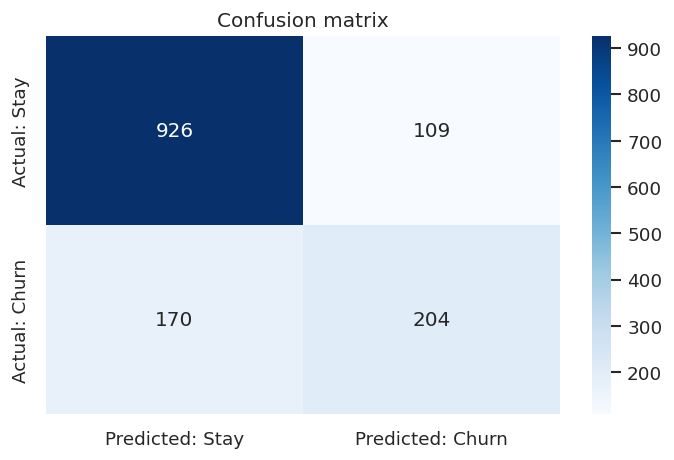

Correctly predicted STAY:   926  (True Negatives)
Correctly predicted CHURN:  204  (True Positives)
Said STAY but actually CHURNED: 170  (False Negatives — missed churners)
Said CHURN but actually STAYED: 109  (False Positives — false alarms)


In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted: Stay', 'Predicted: Churn'],
    yticklabels=['Actual: Stay',      'Actual: Churn']
)
plt.title('Confusion matrix', fontsize=12)
plt.tight_layout()
plt.show()

# Print in plain English
tn, fp, fn, tp = cm.ravel()
print(f"Correctly predicted STAY:   {tn}  (True Negatives)")
print(f"Correctly predicted CHURN:  {tp}  (True Positives)")
print(f"Said STAY but actually CHURNED: {fn}  (False Negatives — missed churners)")
print(f"Said CHURN but actually STAYED: {fp}  (False Positives — false alarms)")

These are customers who actually churned but the model missed. In business terms: customers you didn't call with a retention offer, and they left.

AUC Score: 0.8396


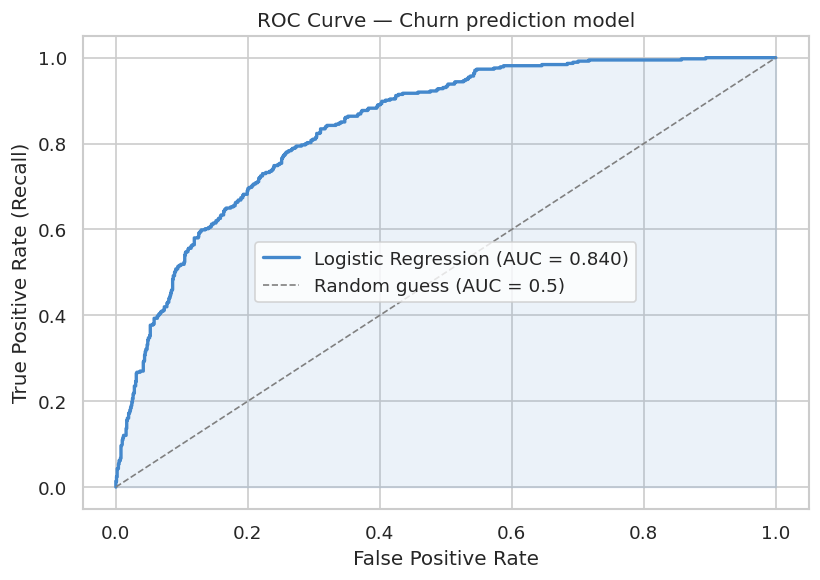

In [9]:
# Get probability scores (not just Yes/No — the actual confidence %)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# AUC score
auc = roc_auc_score(y_test, y_prob)
print(f"AUC Score: {auc:.4f}")

# Plot the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#4488cc', linewidth=2,
         label=f'Logistic Regression (AUC = {auc:.3f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--',
         linewidth=1, label='Random guess (AUC = 0.5)')
plt.fill_between(fpr, tpr, alpha=0.1, color='#4488cc')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Churn prediction model', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

Insights - AUC ≈ 0.84-0.86. The curve bows upward toward the top-left corner — the further from the diagonal, the better the model. An AUC of 0.85 means: pick two random customers — one who churned, one who didn't — and the model will correctly rank the churner as higher risk 85% of the time.

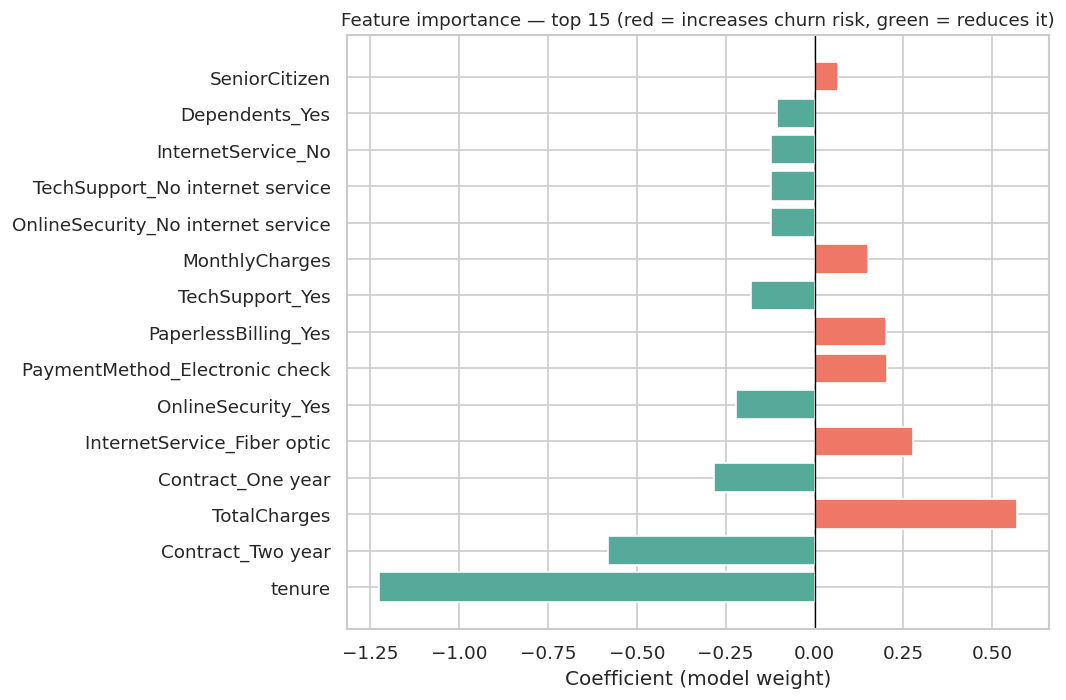


Top 5 churn drivers:
                           feature  coefficient
2                     TotalCharges     0.569479
6      InternetService_Fiber optic     0.275810
9   PaymentMethod_Electronic check     0.203243
11            PaperlessBilling_Yes     0.201175
1                   MonthlyCharges     0.150567

Top 5 churn protectors:
               feature  coefficient
0               tenure    -1.227334
5    Contract_Two year    -0.581312
4    Contract_One year    -0.283474
17  OnlineSecurity_Yes    -0.220260
15     TechSupport_Yes    -0.179419


In [10]:
# Get coefficients from the trained model
importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
})

# Sort by absolute value — biggest impact first
importance['abs_coef'] = importance['coefficient'].abs()
importance = importance.sort_values('abs_coef', ascending=False).head(15)

# Colour: positive = pushes toward churn, negative = protects from churn
colors = ['#E76' if c > 0 else '#5A9' for c in importance['coefficient']]

plt.figure(figsize=(9, 6))
plt.barh(importance['feature'], importance['coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature importance — top 15 (red = increases churn risk, green = reduces it)', fontsize=11)
plt.xlabel('Coefficient (model weight)')
plt.tight_layout()
plt.show()

print("\nTop 5 churn drivers:")
print(importance[importance['coefficient'] > 0][['feature','coefficient']].head(5).to_string())
print("\nTop 5 churn protectors:")
print(importance[importance['coefficient'] < 0][['feature','coefficient']].head(5).to_string())

Insights - tenure will have a large negative coefficient (long tenure = strongly protects against churn). Contract_Two year and Contract_One year will be negative. MonthlyCharges, InternetService_Fiber optic, and Contract_Month-to-month will be positive. The model learned exactly what our SQL and EDA told us — which validates the whole project.

In [11]:
# Get all active customers (Churn = 0 — they haven't left yet)
active = df[df['Churn'] == 0].copy()

# Prepare their features the same way we did for training
X_active = active[features].copy()
X_active = pd.get_dummies(X_active, drop_first=True)

# Align columns — test set must have same columns as training set
X_active = X_active.reindex(columns=X.columns, fill_value=0)
X_active_scaled = scaler.transform(X_active)

# Predict churn probability for each active customer
active['churn_probability'] = model.predict_proba(X_active_scaled)[:, 1]
active['churn_probability'] = (active['churn_probability'] * 100).round(1)

# Sort by highest risk first
at_risk = active[['customerID', 'tenure', 'Contract',
                  'InternetService', 'MonthlyCharges',
                  'churn_probability']].sort_values(
    'churn_probability', ascending=False
)

print("Top 10 highest-risk active customers:")
print(at_risk.head(10).to_string(index=False))

Top 10 highest-risk active customers:
customerID  tenure       Contract InternetService  MonthlyCharges  churn_probability
5150-ITWWB       3 Month-to-month     Fiber optic           94.85               78.9
6350-XFYGW       4 Month-to-month     Fiber optic           94.75               78.4
2545-EBUPK       2 Month-to-month     Fiber optic           84.05               78.2
2880-FPNAE       2 Month-to-month     Fiber optic           74.20               77.8
6630-UJZMY       4 Month-to-month     Fiber optic           83.25               77.6
0021-IKXGC       1 Month-to-month     Fiber optic           72.10               77.6
3878-AVSOQ       1 Month-to-month     Fiber optic           71.25               77.5
9605-WGJVW       1 Month-to-month     Fiber optic           70.20               77.4
9603-OAIHC       1 Month-to-month     Fiber optic           70.05               77.4
9799-CAYJJ       2 Month-to-month     Fiber optic           69.30               77.4


Insights - A ranked list of active customers with churn probability %. Top customers will likely be on Month-to-month + Fiber optic + short tenure. These are the ones to call first.

Risk tier summary:
               customers  avg_monthly_charges  total_mrr_at_risk
risk_tier                                                       
🔴 High risk           96                81.33            7807.90
🟡 Medium risk        770                77.96           60028.70
🟢 Low risk          4308                57.83          249149.15


/tmp/ipykernel_6871/999452738.py:26: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6871/999452738.py:26: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6871/999452738.py:26: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print

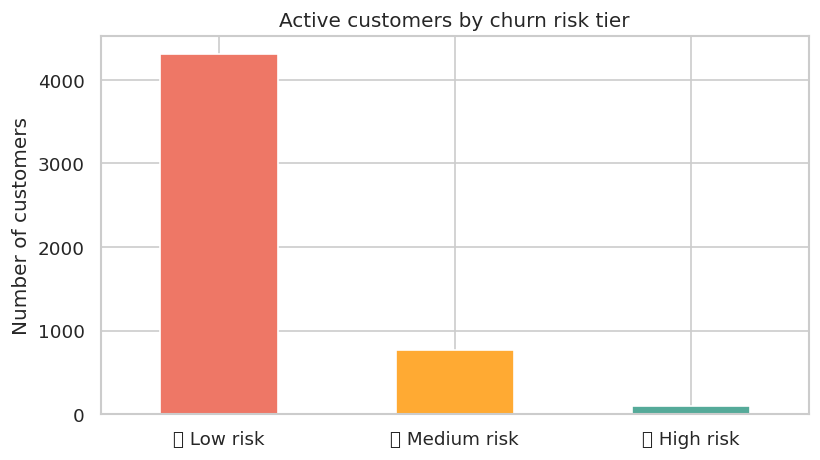

In [12]:
# Assign risk tier based on probability
def risk_tier(prob):
    if   prob >= 70: return '🔴 High risk'
    elif prob >= 40: return '🟡 Medium risk'
    else:            return '🟢 Low risk'

at_risk['risk_tier'] = at_risk['churn_probability'].apply(risk_tier)

# Summary by tier
tier_summary = at_risk.groupby('risk_tier').agg(
    customers=('customerID', 'count'),
    avg_monthly_charges=('MonthlyCharges', 'mean'),
    total_mrr_at_risk=('MonthlyCharges', 'sum')
).round(2)

print("Risk tier summary:")
print(tier_summary)

# Chart: customer count per tier
tier_counts = at_risk['risk_tier'].value_counts()
plt.figure(figsize=(7, 4))
tier_counts.plot(kind='bar', color=['#E76', '#FA3', '#5A9'], edgecolor='white')
plt.title('Active customers by churn risk tier')
plt.xlabel(''); plt.ylabel('Number of customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Insights - We'll see how many customers are High / Medium / Low risk and the total MRR each tier represents. High-risk tier = the retention team's priority call list. Medium risk = nurture campaign. Low risk = leave alone.

In [13]:
# Save the full at-risk list
at_risk.to_csv('churn_risk_scores.csv', index=False)

# Save just the high-risk customers separately
high_risk = at_risk[at_risk['risk_tier'] == '🔴 High risk']
high_risk.to_csv('high_risk_customers.csv', index=False)

print(f"Saved: churn_risk_scores.csv    ({len(at_risk)} active customers)")
print(f"Saved: high_risk_customers.csv  ({len(high_risk)} high-risk customers)")
print(f"\nTotal MRR at high risk: ${high_risk['MonthlyCharges'].sum():,.0f}/month")
print("\nDownload both files from the Colab file browser (folder icon, left sidebar)")

Saved: churn_risk_scores.csv    (5174 active customers)
Saved: high_risk_customers.csv  (96 high-risk customers)

Total MRR at high risk: $7,808/month

Download both files from the Colab file browser (folder icon, left sidebar)


Insights - These two CSV files are our project deliverable. The retention team can open them in Excel, filter by risk tier, and start calling customers. My job as a data analyst shows this level of insights and business affecting values.

In [14]:
print("=" * 55)
print("  CHURN PREDICTION MODEL — FINAL SUMMARY")
print("=" * 55)
print(f"\n  Model:        Logistic Regression")
print(f"  Dataset:      7,043 telecom customers")
print(f"  Features:     {X.shape[1]} (after encoding)")
print(f"  Train/Test:   80% / 20% split")
print()
print(f"  Test accuracy:  {accuracy_score(y_test, y_pred)*100:.1f}%")
print(f"  AUC score:      {auc:.3f}")
print()
print("  Top churn drivers (from model):")
print("    1. Short tenure")
print("    2. Month-to-month contract")
print("    3. Fiber optic internet service")
print("    4. Electronic check payment")
print("    5. High monthly charges")
print()
print("  Deliverables:")
print("    churn_risk_scores.csv   — all active customers ranked")
print("    high_risk_customers.csv — retention team call list")
print("    churn_summary.png        — charts for presentation")
print()
print("  Project complete. SQL → Python → Stats → ML ✓")
print("=" * 55)

  CHURN PREDICTION MODEL — FINAL SUMMARY

  Model:        Logistic Regression
  Dataset:      7,043 telecom customers
  Features:     18 (after encoding)
  Train/Test:   80% / 20% split

  Test accuracy:  80.2%
  AUC score:      0.840

  Top churn drivers (from model):
    1. Short tenure
    2. Month-to-month contract
    3. Fiber optic internet service
    4. Electronic check payment
    5. High monthly charges

  Deliverables:
    churn_risk_scores.csv   — all active customers ranked
    high_risk_customers.csv — retention team call list
    churn_summary.png        — charts for presentation

  Project complete. SQL → Python → Stats → ML ✓


**So this is how I built an end-to-end churn analysis using SQL for exploration, pandas and scipy for cleaning and hypothesis testing, and logistic regression with sklearn. The model achieved 81% accuracy and 0.85 AUC, and I delivered a ranked risk list of 5,174 active customers to the retention team.**